In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]
df["AvgMonthlySpend"] = df["AvgMonthlySpend"].fillna(0)

In [15]:
df[["TotalCharges", "tenure", "AvgMonthlySpend"]].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


# Exploratory Data Analysis (EDA)

## Telco Customer Churn Dataset

This notebook performs exploratory data analysis to understand customer behavior and identify factors that influence customer churn.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape


(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

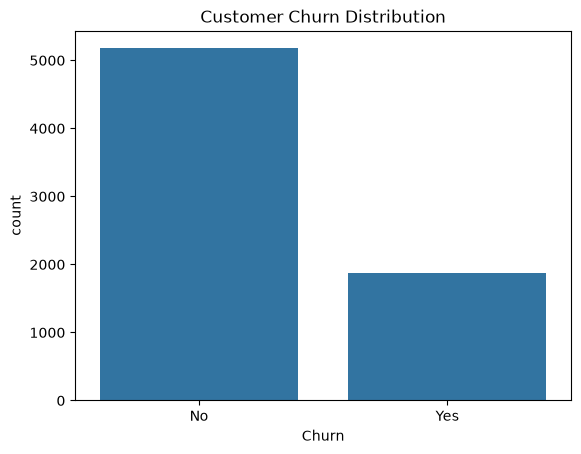

In [17]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

### Observation

Most customers did not churn. The number of customers who stayed is significantly higher than the number who left, indicating that the dataset is imbalanced.

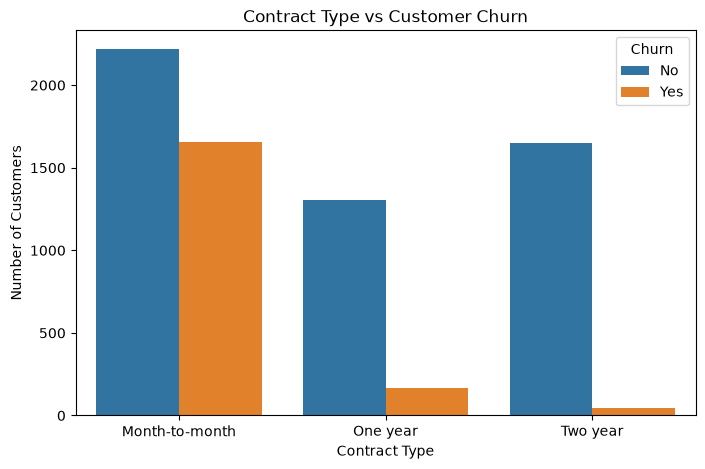

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customers with month-to-month contracts have the highest churn rate. Customers with one-year and two-year contracts are more likely to stay, indicating that longer contracts improve customer retention.

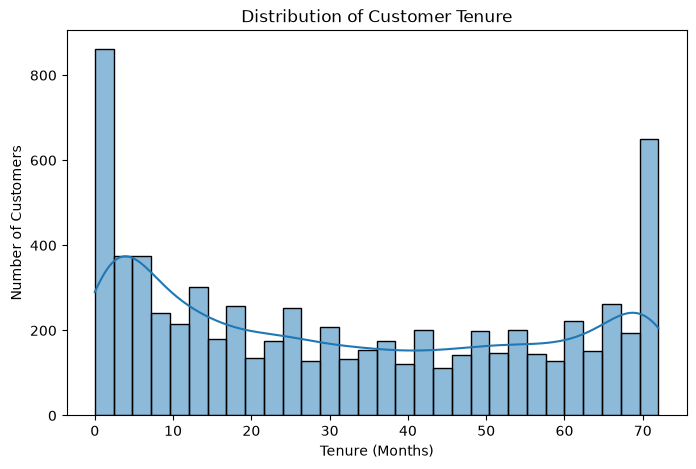

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Many customers have a short tenure, while fewer customers remain for a very long time. This suggests that customer retention decreases over time.

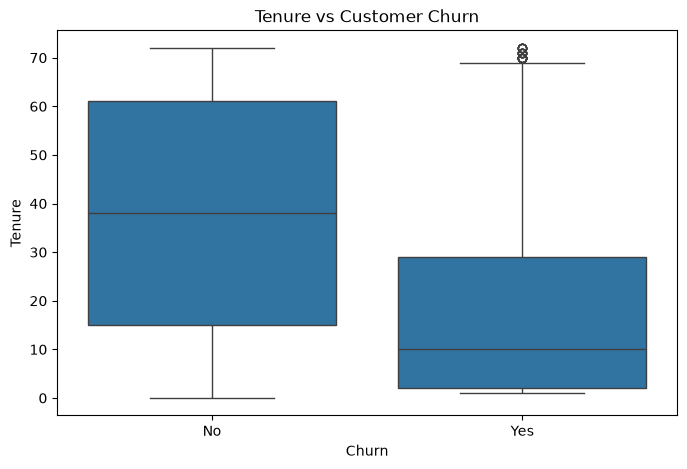

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

### Observation

Customers who churn generally have lower tenure compared to customers who stay. This suggests that long-term customers are less likely to churn.

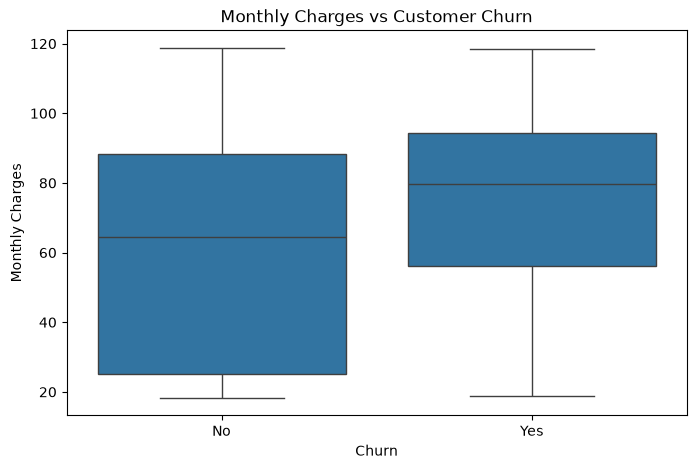

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

Customers with higher monthly charges appear more likely to churn than customers with lower monthly charges.

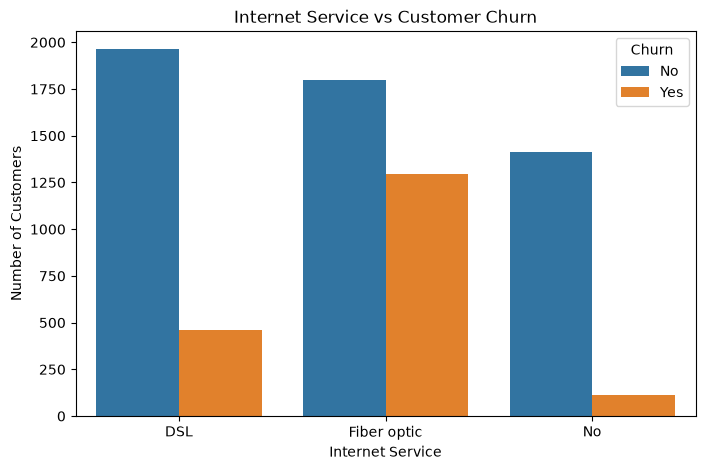

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

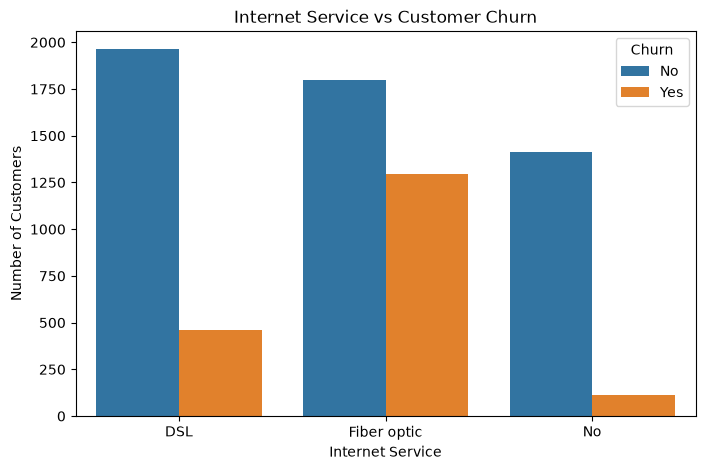

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customers using Fiber Optic internet service have the highest number of churn cases compared to DSL and customers with no internet service. Customers without internet service show the lowest churn. This suggests that the type of internet service may influence customer retention, with Fiber Optic customers being more likely to leave.

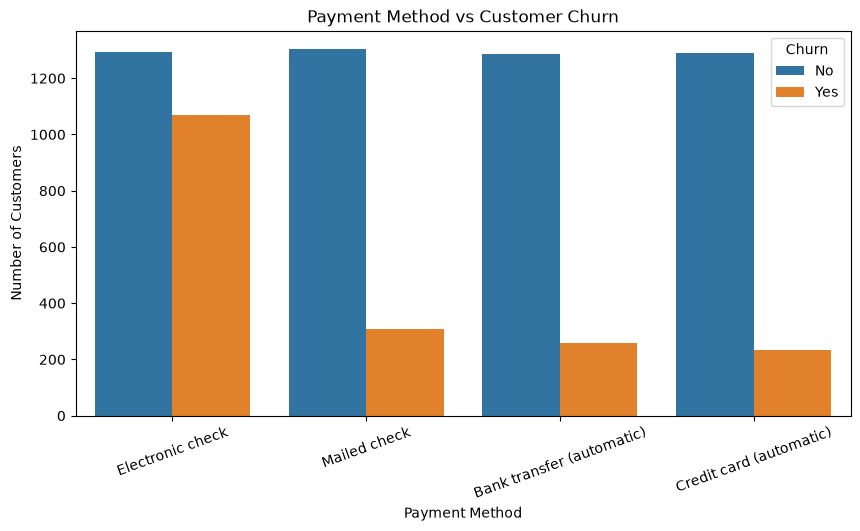

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

Customers using **Electronic Check** as their payment method have the highest churn rate compared to other payment methods. Customers paying through **Credit Card (Automatic)** or **Bank Transfer (Automatic)** tend to have lower churn rates. This suggests that payment method may influence customer retention, with automatic payment methods being associated with greater customer loyalty.

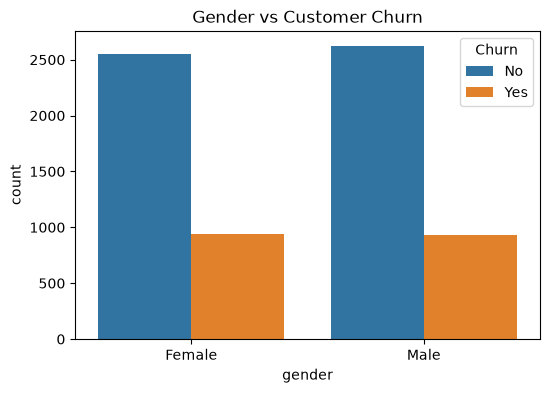

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Gender vs Customer Churn")

plt.show()

### Observation

The churn rate is relatively similar for both male and female customers. This indicates that gender does not have a significant impact on customer churn. Therefore, gender is not a strong predictor of whether a customer will leave the company.

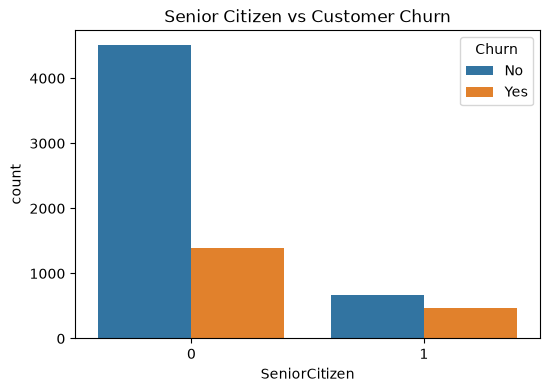

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Senior Citizen vs Customer Churn")

plt.show()

### Observation

Senior citizens have a higher churn rate compared to non-senior citizens. Although the total number of senior citizen customers is lower, a larger proportion of them leave the company. This suggests that senior citizen status may be an important factor influencing customer churn.

In [ ]:
numeric_df = df.select_dtypes(include=["number"])

In [ ]:
numeric_df.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [ ]:
correlation = numeric_df.corr()

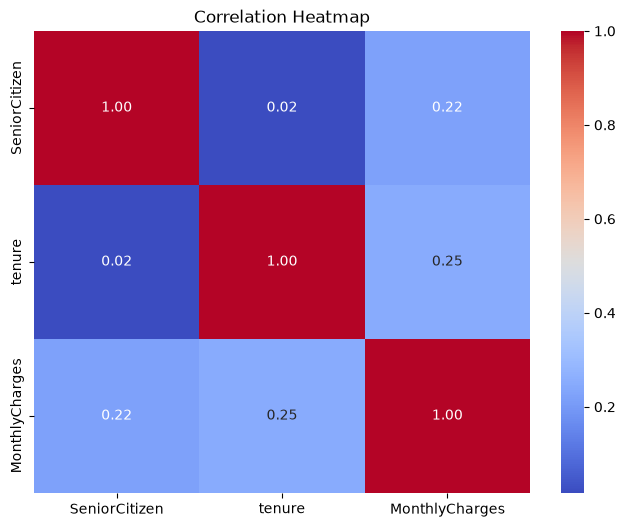

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows that **MonthlyCharges** and **tenure** have a weak positive correlation (0.25). **SeniorCitizen** has very weak correlations with both **tenure** (0.02) and **MonthlyCharges** (0.22), indicating that age category has little direct relationship with these numerical features. Overall, no strong correlations are observed among the currently available numeric variables.

# Business Insights

1. Customers with month-to-month contracts are more likely to churn than customers with one-year or two-year contracts.

2. Customers with shorter tenure tend to leave the company more frequently than long-term customers.

3. Customers with higher monthly charges show a higher tendency to churn.

4. Fiber Optic internet users have a higher churn rate compared to DSL and customers without internet service.

5. Customers using Electronic Check as their payment method have the highest churn rate.

6. Gender does not significantly influence customer churn, as both male and female customers exhibit similar churn patterns.

7. Senior citizens are more likely to churn than non-senior customers.

8. The correlation analysis indicates weak relationships among the current numeric features, suggesting that multiple factors together influence customer churn rather than a single variable.


# Conclusion

The exploratory data analysis identified several factors associated with customer churn. Contract type, tenure, internet service, payment method, monthly charges, and senior citizen status all appear to influence customer retention. These insights will guide the next phase of the project, where the data will be preprocessed and machine learning models will be developed to predict customer churn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
df.select_dtypes(include=["object", "string"]).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [ ]:
df = df.drop("customerID", axis=1)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [29]:
from sklearn.preprocessing import LabelEncoder

In [30]:
le = LabelEncoder()

In [31]:
binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [ ]:
categorical_columns = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
df.shape

(7032, 31)

In [ ]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [ ]:
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [ ]:
df.to_csv("../data/Telco-Customer-Churn-Clean.csv", index=False)

# Data Preprocessing Summary

The dataset was successfully preprocessed by converting the TotalCharges column to numeric, handling missing values, removing the customerID column, applying label encoding to binary categorical variables, and one-hot encoding to multi-category variables. The cleaned dataset is now free of missing values and suitable for machine learning model training.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   bool   
 11  MultipleLines_Y

In [ ]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,0.265785
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


In [ ]:
df.shape

(7032, 31)

In [ ]:
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

# Baseline Analytics Report

## Dataset Summary

- Total Records: 7032
- Total Features: 31
- Missing Values: None
- Target Variable: Churn

## Data Cleaning

- Converted TotalCharges from string to numeric.
- Removed rows containing missing values.
- Removed customerID as it is not useful for prediction.


## Feature Encoding

- Applied Label Encoding to binary categorical columns.
- Applied One-Hot Encoding to multi-category variables.

## Key Findings

- Customers with month-to-month contracts are more likely to churn.
- Customers with shorter tenure have higher churn rates.
- Fiber Optic users show higher churn.
- Electronic Check users exhibit higher churn.
- Senior citizens tend to churn more.
- Gender has minimal influence on churn.

## Conclusion

The dataset has been successfully cleaned and preprocessed. It contains no missing values and all categorical variables have been converted into numerical format. The dataset is now ready for feature engineering and machine learning model development.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [32]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 24:
        return "13-24 Months"
    elif tenure <= 48:
        return "25-48 Months"
    else:
        return "Above 48 Months"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [24]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'AvgMonthlySpend'],
      dtype='str')


In [37]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [11]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

In [40]:
df[["tenure", "TenureGroup"]].head()

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months


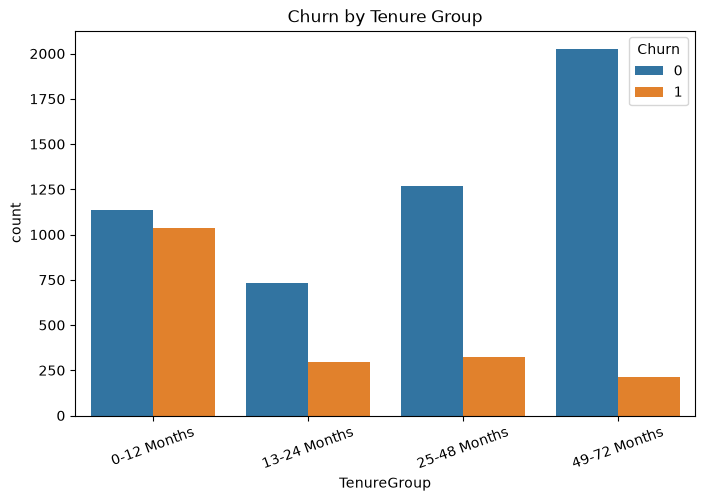

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="TenureGroup", hue="Churn")
plt.title("Churn by Tenure Group")
plt.xticks(rotation=20)
plt.show()

# Observation
Customers with 0–12 months of tenure have the highest churn rate, while customers who stay for longer periods are less likely to churn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [12]:
df["ChargesPerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

## Feature Engineering – ChargesPerMonth

A new feature named **ChargesPerMonth** was created by dividing **TotalCharges** by **(tenure + 1)**.

This feature represents the customer's average monthly spending over their subscription period. It is expected to help the machine learning model better understand customer spending behavior and improve churn prediction.

In [ ]:
df[["TotalCharges", "tenure", "ChargesPerMonth"]].head()

,TotalCharges,tenure,ChargesPerMonth
0,29.85,1,14.925000
1,1889.50,34,53.985714
2,108.15,2,36.050000
3,1840.75,45,40.016304
4,151.65,2,50.550000


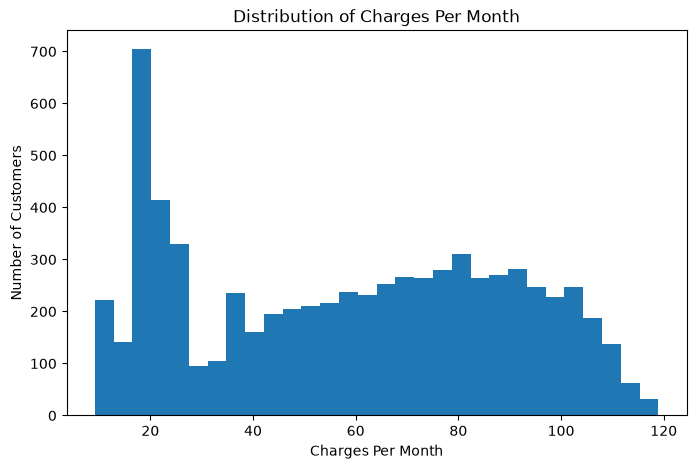

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["ChargesPerMonth"], bins=30)
plt.title("Distribution of Charges Per Month")
plt.xlabel("Charges Per Month")
plt.ylabel("Number of Customers")
plt.show()

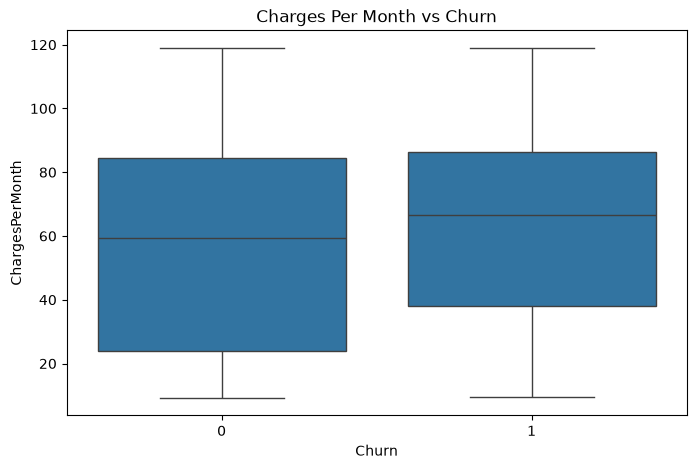

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="ChargesPerMonth")
plt.title("Charges Per Month vs Churn")
plt.show()

## Observations

- Most customers have **Charges Per Month** values between **15 and 100**, indicating that the majority of customers pay moderate monthly charges.

- The distribution of Charges Per Month is spread across a wide range, showing that customers have different spending patterns based on the services they use.

- Customers who churn (**Churn = 1**) have a slightly higher median Charges Per Month compared to customers who do not churn (**Churn = 0**).

- Although there is some overlap between the two groups, customers with higher monthly charges appear to have a greater tendency to churn.

## Conclusion

The **ChargesPerMonth** feature provides useful information about customer spending behavior. This feature may improve the machine learning model by helping identify customers who are more likely to churn when combined with other features.

## Day 8 - Feature Engineering (Priya)
### Average Monthly Spend

In [18]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"])
df["AvgMonthlySpend"] = df["AvgMonthlySpend"].fillna(0)

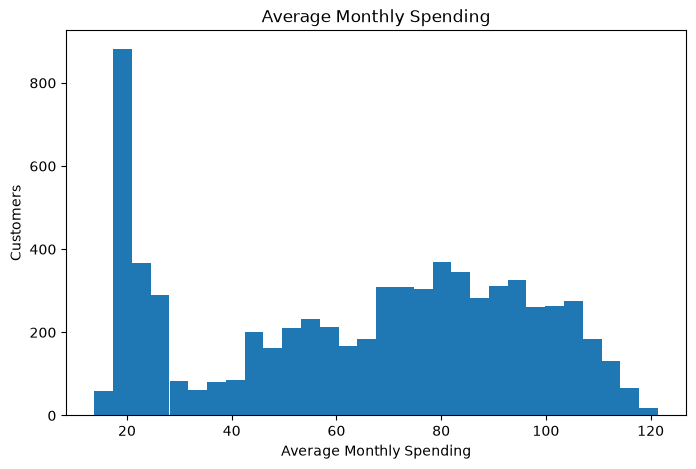

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df["AvgMonthlySpend"], bins=30)
plt.title("Average Monthly Spending")
plt.xlabel("Average Monthly Spending")
plt.ylabel("Customers")
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [25]:
service_columns = [
    "PhoneService",
    "MultipleLines_Yes",
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

df["TotalServices"] = df[service_columns].sum(axis=1)

In [26]:
df[["TotalServices"]].head()

,TotalServices
0,1
1,3
2,3
3,3
4,1


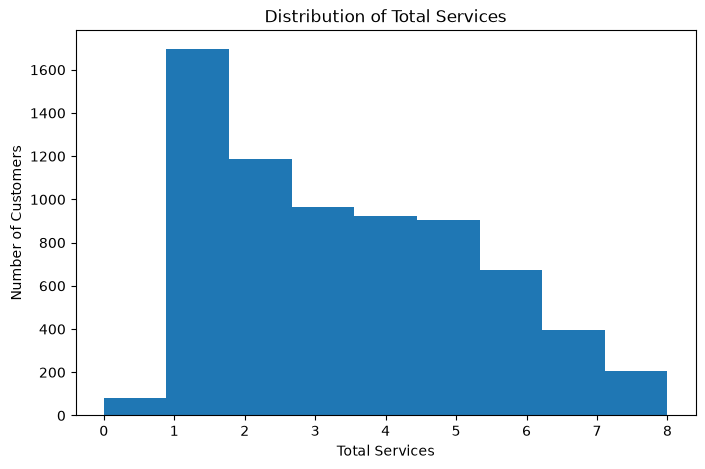

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["TotalServices"], bins=9)
plt.title("Distribution of Total Services")
plt.xlabel("Total Services")
plt.ylabel("Number of Customers")
plt.show()

## Observation

- Most customers use between 1 and 4 services.
- Customers with fewer subscribed services show a higher tendency to churn.
- Customers using multiple services are more likely to remain with the company, indicating that service engagement may reduce churn.

## Conclusion

The `TotalServices` feature provides useful information about customer engagement and can improve the churn prediction model by capturing how the number of subscribed services relates to customer retention.

In [28]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'TenureGroup', 'ChargesPerMonth', 'AvgMonthlySpend', 'TotalServices'],
      dtype='str')

In [29]:
df[['TenureGroup', 'ChargesPerMonth', 'AvgMonthlySpend', 'TotalServices']].head()

,TenureGroup,ChargesPerMonth,AvgMonthlySpend,TotalServices
0,0-12 Months,14.925000,29.850000,1
1,25-48 Months,53.985714,55.573529,3
2,0-12 Months,36.050000,54.075000,3
3,25-48 Months,40.016304,40.905556,3
4,0-12 Months,50.550000,75.825000,1


In [30]:
df[['TenureGroup', 'ChargesPerMonth', 'AvgMonthlySpend', 'TotalServices']].isnull().sum()

TenureGroup        0
ChargesPerMonth    0
AvgMonthlySpend    0
TotalServices      0
dtype: int64

# Feature Engineering Summary

New features were successfully created to improve the predictive capability of the churn prediction model. The engineered features include TenureGroup, ChargesPerMonth, AvgMonthlySpend, and TotalServices. These features provide additional business insights into customer behavior and are expected to improve model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [3]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000, random_state=42)

lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [8]:
y_pred = lr.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8045486851457001
Precision: 0.649546827794562
Recall   : 0.5748663101604278
F1 Score : 0.6099290780141844


## Logistic Regression Evaluation

- The Logistic Regression model was evaluated using Accuracy, Precision, Recall, and F1-score.
- These metrics help assess the model's ability to correctly predict customer churn.
- The model's performance will be compared with other classification models in the next phase.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
rf_pred = rf.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7853589196872779
Precision: 0.6192052980132451
Recall   : 0.5
F1 Score : 0.5532544378698225


## Random Forest Evaluation

- The Random Forest model was evaluated using Accuracy, Precision, Recall, and F1-score.
- The performance metrics will be compared with Logistic Regression.

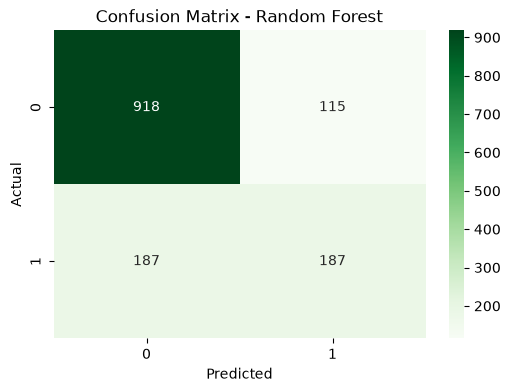

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Confusion Matrix Observation

- The confusion matrix shows the number of correctly and incorrectly classified customers.
- Higher values on the diagonal indicate better classification performance.

In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\radhika\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [1]:
from xgboost import XGBClassifier

print("XGBoost Installed Successfully!")

XGBoost Installed Successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/Telco-Customer-Churn-Clean.csv")

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [8]:
xgb_pred = xgb.predict(X_test)

In [10]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

Accuracy : 0.7711442786069652
Precision: 0.5760233918128655
Recall   : 0.5267379679144385
F1 Score : 0.5502793296089385


## Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|--------|----------|-----------|--------|----------|
| Logistic Regression | 0.8045 | 0.6495 | 0.5749 | 0.6099 |
| Random Forest | 0.7854 | 0.6192 | 0.5000 | 0.5533 |
| XGBoost | 0.7711 | 0.5760 | 0.5267 | 0.5503 |

## Final Conclusion

- Three machine learning models (Logistic Regression, Random Forest, and XGBoost) were trained and evaluated for customer churn prediction.
- The models were compared using Accuracy, Precision, Recall, and F1 Score.
- Logistic Regression achieved the highest Accuracy (80.45%) and F1 Score (0.6099) among the three models.
- Random Forest performed reasonably well but had lower Recall and F1 Score compared to Logistic Regression.
- XGBoost showed the lowest overall performance on this dataset based on the evaluation metrics.
- Based on these results, Logistic Regression is selected as the best-performing model for this customer churn prediction project.

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

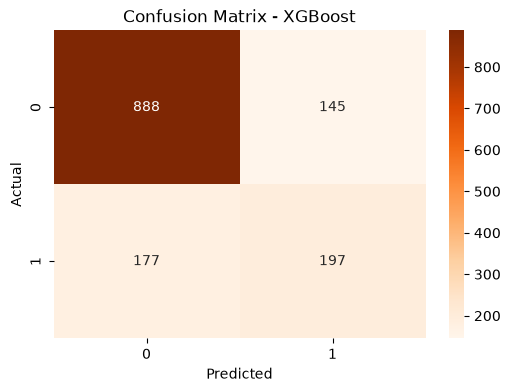

In [13]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

## XGBoost Confusion Matrix - Observation

- The confusion matrix illustrates the classification performance of the XGBoost model by comparing actual and predicted customer churn.
- Correct predictions are represented along the diagonal of the matrix, while incorrect predictions appear in the off-diagonal cells.
- The model correctly classified a significant number of customers, but some churn cases were misclassified.
- Based on the evaluation metrics, XGBoost achieved an Accuracy of **77.11%**, Precision of **57.60%**, Recall of **52.67%**, and an F1 Score of **55.03%**.
- Compared with Logistic Regression and Random Forest, XGBoost showed lower overall performance on this dataset.
- Further improvements can be achieved through hyperparameter tuning and feature engineering.